In [29]:
# --- Imports ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import unicodedata
import re
import datetime
import networkx as nx
from itertools import combinations
import pycountry
import plotly.graph_objects as go

# Loading and Cleaning

In [30]:

# --- Data Loading & Cleaning for Flattened OpenAlex ---
def load_and_clean_your_csv(file_path):
    """
    Cleans the flattened OpenAlex CSV structure found in your research01 file.
    """
    df = pd.read_csv(file_path)
    
    # 1. Standardize Numeric Columns
    df['publication_year'] = pd.to_numeric(df['publication_year'], errors='coerce')
    df['cited_by_count'] = pd.to_numeric(df['cited_by_count'], errors='coerce').fillna(0)
    
    # 2. Extract Primary Author (takes the first name before the first '|')
    def get_primary_author(name_str):
        if pd.isna(name_str): return "Unknown"
        return str(name_str).split('|')[0]

    # 3. Handle Topics/Keywords (using the 'primary_topic.display_name' column)
    # Note: If you want to use the full topic string, we keep it as is.
    df['primary_author'] = df['authorships.author.display_name'].apply(get_primary_author)
    
    return df

# Load your specific file
df_clean = load_and_clean_your_csv('research02_works-csv-Vda3njn3VwEnvWU2f6fE5n.csv')


In [31]:
df_clean.head()

,id,abstract,authorships.author.display_name,authorships.author.id,authorships.author.orcid,authorships.countries,authorships.institutions.display_name,authorships.institutions.id,authorships.is_corresponding,best_oa_location.license,...,open_access.oa_status,primary_location.source.display_name,primary_location.source.id,primary_location.source.issn_l,primary_location.source.type,primary_topic.display_name,publication_date,publication_year,type,primary_author
0,https://openalex.org/W2070911198,NaN,Yanfang Ma|Jiuping Xu,https://openalex.org/A5100909062|https://opena...,|https://orcid.org/0000-0003-3756-3969,CN|CN,Sichuan University|Sichuan University|State Ke...,https://openalex.org/I24185976|https://openale...,False|True,NaN,...,closed,Engineering Optimization,https://openalex.org/S139857051,0305-215X,journal,Vehicle Routing Optimization Methods,2014-06-30,2014,article,Yanfang Ma
1,https://openalex.org/W4211132698,NaN,Merve Cengiz Toklu,https://openalex.org/A5067026110,https://orcid.org/0000-0001-9609-5136,TR,Sakarya University,https://openalex.org/I103703290,True,NaN,...,closed,Journal of Intelligent Manufacturing,https://openalex.org/S161464388,0956-5515,journal,Facility Location and Emergency Management,2022-02-11,2022,article,Merve Cengiz Toklu
2,https://openalex.org/W2999440819,NaN,Sadia Samar Ali|Turan Paksoy|Belkız Torğul|Raj...,https://openalex.org/A5073413581|https://opena...,https://orcid.org/0000-0003-4911-5725|https://...,|||,NaN,NaN,True|False|False|False,NaN,...,closed,Wireless Networks,https://openalex.org/S205498627,1022-0038,journal,Sustainable Supply Chain Management,2020-01-11,2020,article,Sadia Samar Ali
3,https://openalex.org/W2254975279,NaN,Yanfang Ma|Jiuping Xu,https://openalex.org/A5100909062|https://opena...,|https://orcid.org/0000-0003-3756-3969,|,NaN,NaN,True|False,NaN,...,closed,NaN,NaN,NaN,NaN,Advanced Manufacturing and Logistics Optimization,2014-06-10,2014,article,Yanfang Ma
4,https://openalex.org/W854438218,NaN,Fatemeh Torfi|Reza Zanjirani Farahani|Iraj Mah...,https://openalex.org/A5005736969|https://opena...,|https://orcid.org/0000-0002-7383-4714|https:/...,IR|GB|IR,Mazandaran University of Science and Technolog...,https://openalex.org/I123173325|https://openal...,False|False|True,NaN,...,closed,Applied Mathematical Modelling,https://openalex.org/S153281200,0307-904X,journal,Multi-Criteria Decision Making,2015-07-04,2015,article,Fatemeh Torfi


In [32]:
# --- Rigorous cleaning (accents and extrange characters) --- #

def rigorous_clean(text):
    if not isinstance(text, str):
        return text
    
    # 1. Remove the '' and non-printable artifacts
    # This encodes to ASCII and ignores anything it can't translate
    text = text.encode("ascii", "ignore").decode("ascii")
    
    # 2. Normalize to remove accents correctly
    nksel = unicodedata.normalize('NFKD', text)
    clean_text = "".join([c for c in nksel if not unicodedata.combining(c)])
    
    # 3. Use Regex to keep only letters, numbers, pipes (for your separators), and basic punctuation
    # This removes the "weird elements" and extra spaces between letters
    clean_text = re.sub(r'[^a-zA-Z0-9\s|.\-]', '', clean_text)
    
    # 4. Collapse multiple spaces into one
    clean_text = re.sub(r'\s+', ' ', clean_text).strip()
    
    return clean_text

# Apply to your columns
cols_to_fix = ['authorships.author.display_name', 'display_name', 'primary_topic.display_name']

for col in cols_to_fix:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].apply(rigorous_clean)

print("Rigorous cleaning finished. No more squares or extra spaces.")

Rigorous cleaning finished. No more squares or extra spaces.


In [33]:
df_clean.head()

,id,abstract,authorships.author.display_name,authorships.author.id,authorships.author.orcid,authorships.countries,authorships.institutions.display_name,authorships.institutions.id,authorships.is_corresponding,best_oa_location.license,...,open_access.oa_status,primary_location.source.display_name,primary_location.source.id,primary_location.source.issn_l,primary_location.source.type,primary_topic.display_name,publication_date,publication_year,type,primary_author
0,https://openalex.org/W2070911198,NaN,Yanfang Ma|Jiuping Xu,https://openalex.org/A5100909062|https://opena...,|https://orcid.org/0000-0003-3756-3969,CN|CN,Sichuan University|Sichuan University|State Ke...,https://openalex.org/I24185976|https://openale...,False|True,NaN,...,closed,Engineering Optimization,https://openalex.org/S139857051,0305-215X,journal,Vehicle Routing Optimization Methods,2014-06-30,2014,article,Yanfang Ma
1,https://openalex.org/W4211132698,NaN,Merve Cengiz Toklu,https://openalex.org/A5067026110,https://orcid.org/0000-0001-9609-5136,TR,Sakarya University,https://openalex.org/I103703290,True,NaN,...,closed,Journal of Intelligent Manufacturing,https://openalex.org/S161464388,0956-5515,journal,Facility Location and Emergency Management,2022-02-11,2022,article,Merve Cengiz Toklu
2,https://openalex.org/W2999440819,NaN,Sadia Samar Ali|Turan Paksoy|Belkz Torul|Rajbi...,https://openalex.org/A5073413581|https://opena...,https://orcid.org/0000-0003-4911-5725|https://...,|||,NaN,NaN,True|False|False|False,NaN,...,closed,Wireless Networks,https://openalex.org/S205498627,1022-0038,journal,Sustainable Supply Chain Management,2020-01-11,2020,article,Sadia Samar Ali
3,https://openalex.org/W2254975279,NaN,Yanfang Ma|Jiuping Xu,https://openalex.org/A5100909062|https://opena...,|https://orcid.org/0000-0003-3756-3969,|,NaN,NaN,True|False,NaN,...,closed,NaN,NaN,NaN,NaN,Advanced Manufacturing and Logistics Optimization,2014-06-10,2014,article,Yanfang Ma
4,https://openalex.org/W854438218,NaN,Fatemeh Torfi|Reza Zanjirani Farahani|Iraj Mah...,https://openalex.org/A5005736969|https://opena...,|https://orcid.org/0000-0002-7383-4714|https:/...,IR|GB|IR,Mazandaran University of Science and Technolog...,https://openalex.org/I123173325|https://openal...,False|False|True,NaN,...,closed,Applied Mathematical Modelling,https://openalex.org/S153281200,0307-904X,journal,Multi-Criteria Decision Making,2015-07-04,2015,article,Fatemeh Torfi


# Function Creation

In [34]:

# --- Production Over Time ---
def plot_production_trends(df):
    # Filter years to match your study range (e.g., 2015-2025)
    yearly_counts = df[df['publication_year'] >= 2000]['publication_year'].value_counts().sort_index()
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x=yearly_counts.index.astype(int), y=yearly_counts.values, color='gold')
    plt.title('Documents per Year (VRP Review)', fontsize=16)
    plt.xlabel('Year', fontsize=14)
    plt.ylabel('Number of Documents', fontsize=14)
    plt.xticks(fontsize=12) # Increases size of the numbers on the X-axis
    plt.yticks(fontsize=12) # Increases size of the Author Names on the Y-axis
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


In [35]:
## -- Get country name ---##
def get_country_name(code):
    try:
        # Translates 'MX' -> 'Mexico', 'CN' -> 'China', etc.
        return pycountry.countries.get(alpha_2=code).name
    except:
        return code # Returns original code if translation fails


In [36]:
# --- Filtered Topic Analysis ---
def plot_real_trends(df):
    """
    Excludes the broad search terms to see the underlying application 
    areas for Hybrid Augmented Intelligence.
    """
    # 1. Define the terms to remove (VRP and its obvious synonyms)
    exclude_list = [
        'vehicle routing problem', 
        'vrp', 
        'vehicle routing optimization methods',
        'routing optimization'
    ]
    
    # 2. Get the value counts of the primary topic column
    topic_counts = df['primary_topic.display_name'].value_counts()
    
    # 3. Filter the series using a negative regex match
    # This keeps only topics that DO NOT contain our exclusion terms
    pattern = '|'.join(exclude_list)
    filtered_topics = topic_counts[~topic_counts.index.str.contains(pattern, case=False, na=False)]
    
    # 4. Grab the top 10 for the visualization
    top_10_real = filtered_topics.head(10)
    
    # 5. Visualization
    plt.figure(figsize=(15, 6))
    sns.barplot(x=top_10_real.values, y=top_10_real.index, palette='magma')
    plt.title('Top 10 Research Domains (VRP Terms Removed)', fontsize=14)
    plt.xlabel('Number of Articles')
    plt.ylabel('')
    plt.xticks(fontsize=12) # Increases size of the numbers on the X-axis
    plt.yticks(fontsize=12) # Increases size of the Author Names on the Y-axis
    plt.tight_layout()
    plt.show()



In [37]:
# --- Top Cited Articles (Identification of Influential Works) ---
def show_top_cited(df):
    """Shows the most influential papers for your review."""
    top_papers = df[['display_name', 'primary_author', 'publication_year', 'cited_by_count']].sort_values(by='cited_by_count', ascending=False).head(10)
    return top_papers


In [38]:
##--- Plot top stats ----

def plot_top_stats(df, category='author', metric='publications', top_n=10, 
                    citation_col='cited_by_count', separator='|'):
    """
    Unified function adjusted for your specific research01 dataset column names.
    """
    
    # 1. Map generic categories to YOUR specific DataFrame column names
    column_map = {
        'author': 'authorships.author.display_name',
        'institution': 'authorships.institutions.display_name',
        'country': 'authorships.countries'  
    }
    
    target_col = column_map.get(category.lower())
    
    if not target_col or target_col not in df.columns:
        print(f"Error: Category '{category}' invalid or column '{target_col}' missing.")
        return

    # 2. Pre-process: Copy only needed columns
    cols_needed = [target_col]
    if metric == 'citations':
        cols_needed.append(citation_col)
    df_temp = df[cols_needed].copy()
    
    # 3. Clean and Explode (Split values by the pipe '|')
    df_temp[target_col] = df_temp[target_col].fillna('').astype(str).str.split(separator)
    exploded = df_temp.explode(target_col)

    # 4. Rigorous Cleaning
    if category == 'author':
        exploded[target_col] = exploded[target_col].apply(rigorous_clean)
    elif category == 'country':
        # Translate codes to names
        exploded[target_col] = exploded[target_col].str.strip().apply(get_country_name)
    else:
        exploded[target_col] = exploded[target_col].str.strip()

    # Remove garbage strings (length <= 1)
    exploded = exploded[exploded[target_col].str.len() > 1]
    
    # 5. Calculation Logic
    if metric == 'publications':
        top_data = exploded.groupby(target_col).size().sort_values(ascending=False).head(top_n)
        title_text = f'Top {top_n} {category.capitalize()}s (by Publication Count)'
        x_label = 'Number of Documents'
        palette = 'viridis'

    elif metric == 'citations':
        top_data = exploded.groupby(target_col)[citation_col].sum().sort_values(ascending=False).head(top_n)
        title_text = f'Top {top_n} {category.capitalize()}s (by Total Citations)'
        x_label = 'Total Citations'
        palette = 'rocket'

    # 6. Visualization
    plt.figure(figsize=(12, 8))
    sns.barplot(x=top_data.values, y=top_data.index, palette=palette)
    
    plt.title(title_text, fontsize=16)
    plt.xlabel(x_label, fontsize=14)
    #plt.ylabel(category.capitalize(), fontsize=14)
    plt.ylabel('')
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    plt.show()
    
    return top_data

In [39]:
# --- Filtered database by the last n years ----#
def filter_by_last_n_years(df, n_years):
    """
    Filters the dataframe to include only articles from the last n_years.
    Useful for defining the '2015-2025' timeframe for your review.
    """
    # 1. Ensure publication_year is numeric
    df['publication_year'] = pd.to_numeric(df['publication_year'], errors='coerce')
    
    # 2. Determine the reference year (Current year is 2026)
    current_year = 2026 
    start_year = current_year - n_years
    
    # 3. Create the filtered dataframe
    filtered_df = df[df['publication_year'] >= start_year].copy()
    
    print(f"Original articles: {len(df)}")
    print(f"Articles from {start_year} to {current_year}: {len(filtered_df)}")
    
    return filtered_df

In [40]:
## --- Author clusters ----#
def analyze_author_clusters(df, authors_column, min_collaborations=4, separator='|', 
                            grid_rows=2, grid_cols=2, node_size=500, font_size=10, 
                            edge_width_scale=0.5):
    """
    Plots the top author clusters in a grid layout.
    
    Parameters:
    - df: DataFrame containing the data.
    - authors_column: Name of the column with authors.
    - min_collaborations: Minimum shared papers to create a link.
    - separator: Character separating authors (e.g., '|' or ';').
    - grid_rows, grid_cols: Dimensions of the subplot grid (e.g., 2x2 = top 4 clusters).
    - node_size: Visual size of the author bubbles.
    - font_size: Size of the author names.
    - edge_width_scale: Multiplier for edge thickness.
    """
    
    # --- 1. BUILD THE GRAPH ---
    G = nx.Graph()
    
    # Iterate through publications
    for authors_str in df[authors_column].dropna():
        # Split and clean author names
        authors = [a.strip() for a in str(authors_str).split(separator) if a.strip()]
        
        # Create edges for every pair of co-authors
        if len(authors) > 1:
            for u, v in combinations(authors, 2):
                if G.has_edge(u, v):
                    G[u][v]['weight'] += 1
                else:
                    G.add_edge(u, v, weight=1)

    # --- 2. FILTER & SORT CLUSTERS ---
    # Keep only edges that meet the minimum collaboration threshold
    strong_edges = [(u, v) for u, v, d in G.edges(data=True) if d['weight'] >= min_collaborations]
    G_filtered = G.edge_subgraph(strong_edges).copy()
    
    # Get all connected components (clusters) and sort them by size (largest first)
    # This ensures we prioritize the "most collaborative" groups
    clusters = sorted(nx.connected_components(G_filtered), key=len, reverse=True)
    
    if not clusters:
        print(f"No collaborations found with >= {min_collaborations} shared papers.")
        return

    # --- 3. CREATE THE GRID PLOT ---
    num_plots = grid_rows * grid_cols
    fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(grid_cols * 6, grid_rows * 6))
    
    # Flatten axes array for easy iteration (handles 1x1, 1xN, NxN cases)
    if grid_rows * grid_cols > 1:
        axes = axes.flatten()
    else:
        axes = [axes]

    print(f"Found {len(clusters)} clusters. Showing the top {min(len(clusters), num_plots)}.")

    for i in range(num_plots):
        ax = axes[i]
        
        # If we run out of clusters, hide the empty subplot
        if i >= len(clusters):
            ax.axis('off')
            continue
            
        # Get the subgraph for this specific cluster
        cluster_nodes = clusters[i]
        sub_G = G_filtered.subgraph(cluster_nodes)
        
        # Layout: distinct shape for each cluster
        pos = nx.spring_layout(sub_G, k=0.5, seed=42)
        
        # Dynamic edge thickness based on collaboration count
        weights = [sub_G[u][v]['weight'] for u, v in sub_G.edges()]
        widths = [w * edge_width_scale for w in weights]
        
        # Draw the plot
        nx.draw_networkx_nodes(sub_G, pos, ax=ax, node_size=node_size, node_color='lightblue')
        nx.draw_networkx_edges(sub_G, pos, ax=ax, width=widths, alpha=0.5, edge_color='gray')
        nx.draw_networkx_labels(sub_G, pos, ax=ax, font_size=font_size, font_family="sans-serif")
        
        ax.set_title(f"Cluster #{i+1} ({len(cluster_nodes)} Authors)", fontsize=12)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# --- EXAMPLE USAGE ---
# analyze_author_clusters(
#     df, 
#     authors_column='Authors', 
#     min_collaborations=5, 
#     separator='|',
#     grid_rows=2, 
#     grid_cols=2,   # This will show the top 4 biggest groups
#     node_size=600, 
#     font_size=8
# )

In [41]:
## --- Colaboration clusters --- ##
def analyze_category_clusters(df, category='author', min_shared=4, 
                               grid_rows=2, grid_cols=2, node_size=20, 
                               font_size=12, edge_width_scale=0.5):
    """
    Generalized function to plot collaboration clusters for Authors, Institutions, or Countries.
    """
    
    # 1. Map categories to your specific CSV columns
    column_map = {
        'author': 'authorships.author.display_name',
        'institution': 'authorships.institutions.display_name',
        'country': 'authorships.countries'
    }
    
    target_col = column_map.get(category.lower())
    if not target_col:
        print(f"Error: Category '{category}' not supported.")
        return

    # 2. Country name translation helper
    def translate_country(code):
        try: return pycountry.countries.get(alpha_2=code.strip()).name
        except: return code.strip()

    # 3. Build the Graph
    G = nx.Graph()
    
    for items_str in df[target_col].dropna():
        # Split and clean
        items = [i.strip() for i in str(items_str).split('|') if i.strip()]
        
        # Category-specific cleaning
        if category == 'author':
            items = [rigorous_clean(i) for i in items]
        elif category == 'country':
            items = [translate_country(i) for i in items]
            
        # Get UNIQUE items per paper to find true COLLABORATION (e.g. University A vs University B)
        unique_items = list(set(items))
        
        if len(unique_items) > 1:
            for u, v in combinations(unique_items, 2):
                if G.has_edge(u, v):
                    G[u][v]['weight'] += 1
                else:
                    G.add_edge(u, v, weight=1)

    # 4. Filter strong connections & find clusters
    strong_edges = [(u, v) for u, v, d in G.edges(data=True) if d['weight'] >= min_shared]
    G_filtered = G.edge_subgraph(strong_edges).copy()
    clusters = sorted(nx.connected_components(G_filtered), key=len, reverse=True)
    
    if not clusters:
        print(f"No {category} clusters found with >= {min_shared} shared papers.")
        return

    # 5. Plot Grid
    num_plots = grid_rows * grid_cols
    fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(grid_cols * 6, grid_rows * 6))
    axes = axes.flatten() if num_plots > 1 else [axes]

    print(f"Showing top {min(len(clusters), num_plots)} {category} clusters.")

    for i in range(num_plots):
        ax = axes[i]
        if i >= len(clusters):
            ax.axis('off')
            continue
            
        sub_G = G_filtered.subgraph(clusters[i])
        pos = nx.spring_layout(sub_G, k=0.6, seed=42)
        
        # Scale edge width by weight
        widths = [sub_G[u][v]['weight'] * edge_width_scale for u, v in sub_G.edges()]
        
        nx.draw_networkx_nodes(sub_G, pos, ax=ax, node_size=node_size, node_color='indianred')
        nx.draw_networkx_edges(sub_G, pos, ax=ax, width=widths, alpha=0.4, edge_color='darkgray')
        
        # Dynamic label positioning
        labels = {node: node.replace(' ', '\n') for node in sub_G.nodes()}
        nx.draw_networkx_labels(sub_G, pos, labels=labels, ax=ax, font_size=font_size)
        
        ax.set_title(f"{category.capitalize()} Cluster #{i+1} ({len(clusters[i])} entities)", fontsize=13)
        ax.axis('off')

    plt.tight_layout()
    plt.show()


In [42]:
## --- Sankey diagrams ---##

def plot_sankey_categories(df, categories=['country', 'topic', 'author'], n_items=8):
    # 1. Column Mapping (Specific to your research01.csv)
    column_map = {
        'author': 'authorships.author.display_name',
        'institution': 'authorships.institutions.display_name',
        'country': 'authorships.countries',
        'topic': 'primary_topic.display_name'
    }
    
    # 2. Filtering Logic (VRP Exclusions)
    exclude_vrp = ['vehicle routing problem', 'vrp', 'optimization methods', 'routing optimization']
    pattern = '|'.join(exclude_vrp)

    def get_country_name(code):
        try: return pycountry.countries.get(alpha_2=code).name
        except: return code

    # 3. Processing
    cols = [column_map[c] for c in categories]
    temp_df = df[cols].dropna().copy()

    for cat in categories:
        col = column_map[cat]
        temp_df[col] = temp_df[col].astype(str).str.split('|')
        temp_df = temp_df.explode(col)
        temp_df[col] = temp_df[col].str.strip()
        
        if cat == 'author':
            temp_df[col] = temp_df[col].apply(rigorous_clean)
        elif cat == 'country':
            temp_df[col] = temp_df[col].apply(get_country_name)
        elif cat == 'topic':
            temp_df = temp_df[~temp_df[col].str.contains(pattern, case=False, na=False)]
            # TRUNCATE LONG TOPICS for visual clarity
            temp_df[col] = temp_df[col].apply(lambda x: (x[:25] + '...') if len(x) > 25 else x)

    # Filter for top N to avoid "horrible" clutter
    for cat in categories:
        col = column_map[cat]
        top_items = temp_df[col].value_counts().head(n_items).index
        temp_df = temp_df[temp_df[col].isin(top_items)]

    # 4. Create Links
    links = []
    for i in range(len(categories) - 1):
        source_col = column_map[categories[i]]
        target_col = column_map[categories[i+1]]
        res = temp_df.groupby([source_col, target_col]).size().reset_index(name='value')
        res.columns = ['source', 'target', 'value']
        links.append(res)
    
    sankey_df = pd.concat(links)
    all_nodes = list(pd.concat([sankey_df['source'], sankey_df['target']]).unique())
    node_map = {node: i for i, node in enumerate(all_nodes)}
    
    # 5. Build the Chart with specific "Clean" styling
    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=30,           # More space between boxes
            thickness=15,     # Thinner, more elegant boxes
            line=dict(color="gray", width=0.5),
            label=all_nodes,
            color="royalblue" # Uniform node color for academic look
        ),
        link=dict(
            source=sankey_df['source'].map(node_map),
            target=sankey_df['target'].map(node_map),
            value=sankey_df['value'],
            color="rgba(173, 216, 230, 0.4)" # Light blue transparent links
        )
    )])

    fig.update_layout(
        title_text=f"Mapping the Scientific Landscape: {' > '.join(categories).upper()}",
        font_size=14,
        height=700,
        margin=dict(l=50, r=50, t=80, b=50)
    )
    fig.show()

# Run it with a smaller n_items for a cleaner look
# plot_clean_sankey(df_recent, categories=['country', 'topic', 'author'], n_items=6)

# General Results

## Production Over Time

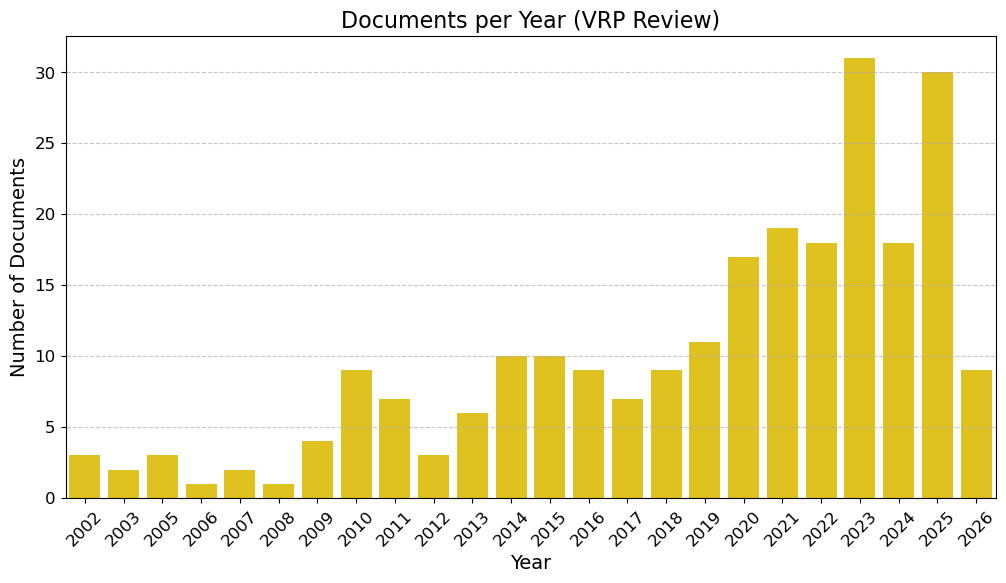

In [43]:

plot_production_trends(df_clean)


## Topic Analysis

/tmp/ipykernel_1792766/2377348178.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_real.values, y=top_10_real.index, palette='magma')


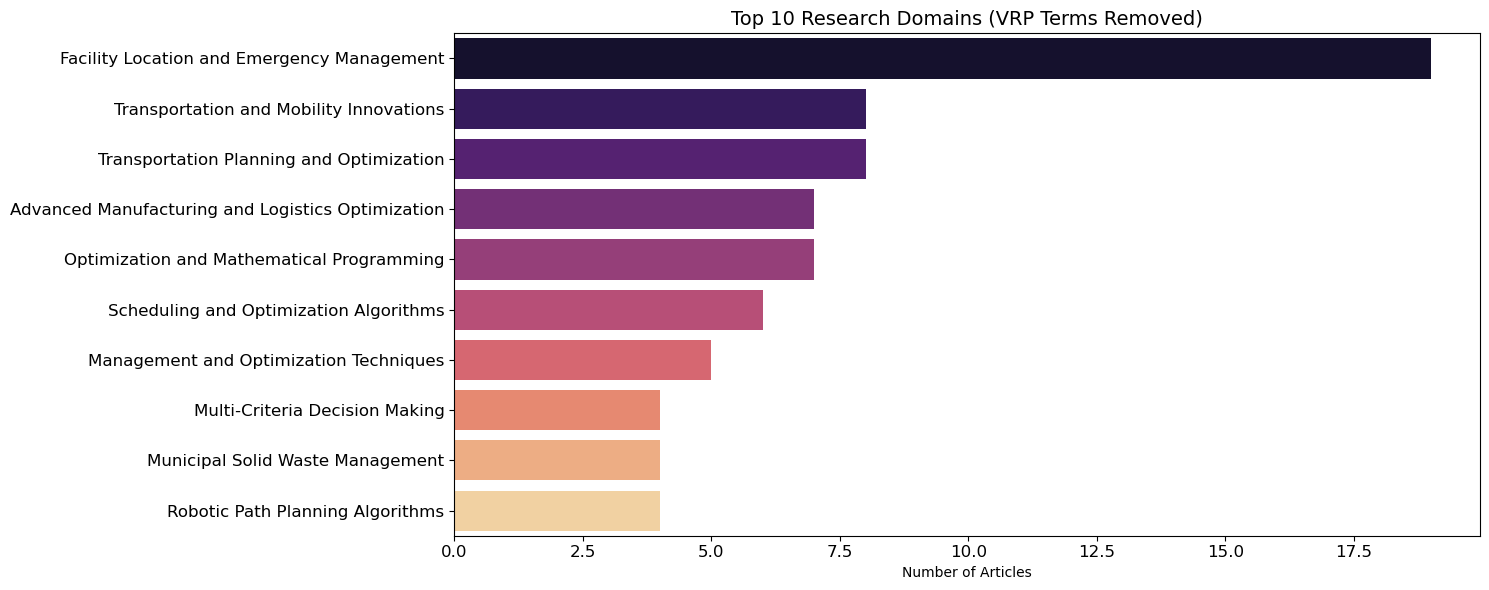

In [44]:

plot_real_trends(df_clean)

## Top Cited Articles

In [45]:

show_top_cited(df_clean)

,display_name,primary_author,publication_year,cited_by_count
101,Heuristic Methods for Location-Allocation Prob...,Leon N. Cooper,1964,532
26,Location-routing problem in multimodal transpo...,Saeed Fazayeli,2018,153
12,An ant colony system empowered variable neighb...,Can B. Kalaycı,2016,141
17,Multi-objective optimization of a two-echelon ...,Alexandra Anderluh,2019,140
57,Two-echelon location-routing optimization with...,Yong Wang,2018,125
8,Deep reinforcement learning for the dynamic an...,Weixu Pan,2022,120
11,ADMM-based problem decomposition scheme for ve...,Yu Yao,2019,118
15,An innovative waste management system in a sma...,Navid Akbarpour,2021,114
22,The SR-GCWS hybrid algorithm for solving the c...,Ángel A. Juan,2009,102
14,Combination of geographical information system...,Christos D. Tarantilis,2003,91


## Top Authors

### Per citations

/tmp/ipykernel_1792766/2788011657.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_data.values, y=top_data.index, palette=palette)


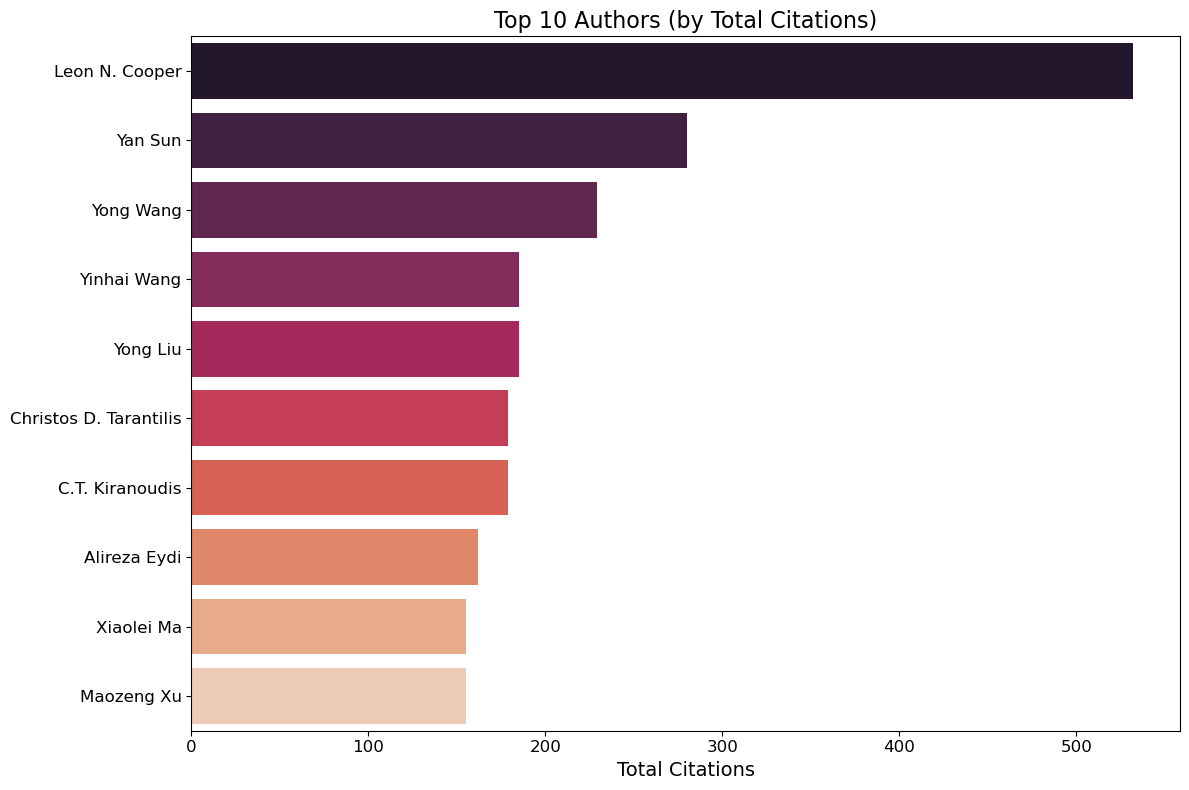

authorships.author.display_name
Leon N. Cooper            532
Yan Sun                   280
Yong Wang                 229
Yinhai Wang               185
Yong Liu                  185
Christos D. Tarantilis    179
C.T. Kiranoudis           179
Alireza Eydi              162
Xiaolei Ma                155
Maozeng Xu                155
Name: cited_by_count, dtype: int64

In [46]:
plot_top_stats(df_clean,category = 'author', metric='citations')

### Per publications

/tmp/ipykernel_1792766/2788011657.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_data.values, y=top_data.index, palette=palette)


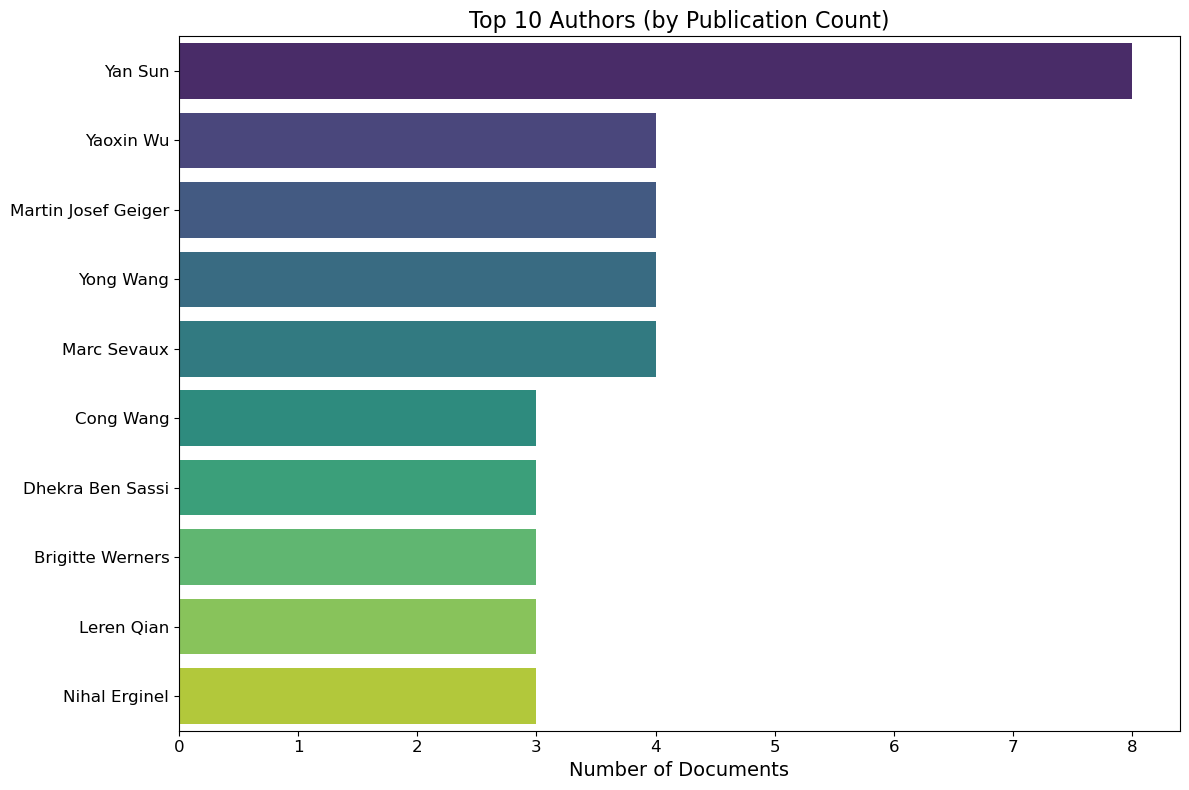

authorships.author.display_name
Yan Sun                8
Yaoxin Wu              4
Martin Josef Geiger    4
Yong Wang              4
Marc Sevaux            4
Cong Wang              3
Dhekra Ben Sassi       3
Brigitte Werners       3
Leren Qian             3
Nihal Erginel          3
dtype: int64

In [48]:
plot_top_stats(df_clean,category = 'author', metric='publications')

# Last 10 Years Results

In [49]:
df_recent = filter_by_last_n_years(df_clean, 11)

# Verify the range
print(f"Minimum year in filtered set: {df_recent['publication_year'].min()}")

Original articles: 248
Articles from 2015 to 2026: 188
Minimum year in filtered set: 2015


In [50]:
df_recent.head()

,id,abstract,authorships.author.display_name,authorships.author.id,authorships.author.orcid,authorships.countries,authorships.institutions.display_name,authorships.institutions.id,authorships.is_corresponding,best_oa_location.license,...,open_access.oa_status,primary_location.source.display_name,primary_location.source.id,primary_location.source.issn_l,primary_location.source.type,primary_topic.display_name,publication_date,publication_year,type,primary_author
1,https://openalex.org/W4211132698,NaN,Merve Cengiz Toklu,https://openalex.org/A5067026110,https://orcid.org/0000-0001-9609-5136,TR,Sakarya University,https://openalex.org/I103703290,True,NaN,...,closed,Journal of Intelligent Manufacturing,https://openalex.org/S161464388,0956-5515,journal,Facility Location and Emergency Management,2022-02-11,2022,article,Merve Cengiz Toklu
2,https://openalex.org/W2999440819,NaN,Sadia Samar Ali|Turan Paksoy|Belkz Torul|Rajbi...,https://openalex.org/A5073413581|https://opena...,https://orcid.org/0000-0003-4911-5725|https://...,|||,NaN,NaN,True|False|False|False,NaN,...,closed,Wireless Networks,https://openalex.org/S205498627,1022-0038,journal,Sustainable Supply Chain Management,2020-01-11,2020,article,Sadia Samar Ali
4,https://openalex.org/W854438218,NaN,Fatemeh Torfi|Reza Zanjirani Farahani|Iraj Mah...,https://openalex.org/A5005736969|https://opena...,|https://orcid.org/0000-0002-7383-4714|https:/...,IR|GB|IR,Mazandaran University of Science and Technolog...,https://openalex.org/I123173325|https://openal...,False|False|True,NaN,...,closed,Applied Mathematical Modelling,https://openalex.org/S153281200,0307-904X,journal,Multi-Criteria Decision Making,2015-07-04,2015,article,Fatemeh Torfi
6,https://openalex.org/W3186940976,NaN,Fatma Demircan Keskin,https://openalex.org/A5041568434,https://orcid.org/0000-0002-7000-4731,TR,Ege University,https://openalex.org/I41641357,True,NaN,...,closed,"Advances in logistics, operations, and managem...",https://openalex.org/S4210223929,2327-350X,book series,Vehicle Routing Optimization Methods,2021-01-01,2021,book-chapter,Fatma Demircan Keskin
8,https://openalex.org/W4224138275,NaN,Weixu Pan|Shi Qiang Liu,https://openalex.org/A5023194872|https://opena...,|https://orcid.org/0000-0002-2370-5519,CN|CN,Fuzhou University|Fuzhou University,https://openalex.org/I80947539|https://openale...,True|False,NaN,...,closed,Applied Intelligence,https://openalex.org/S74726891,0924-669X,journal,Transportation and Mobility Innovations,2022-04-18,2022,article,Weixu Pan


## Topic Analysis

/tmp/ipykernel_1792766/2377348178.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_real.values, y=top_10_real.index, palette='magma')


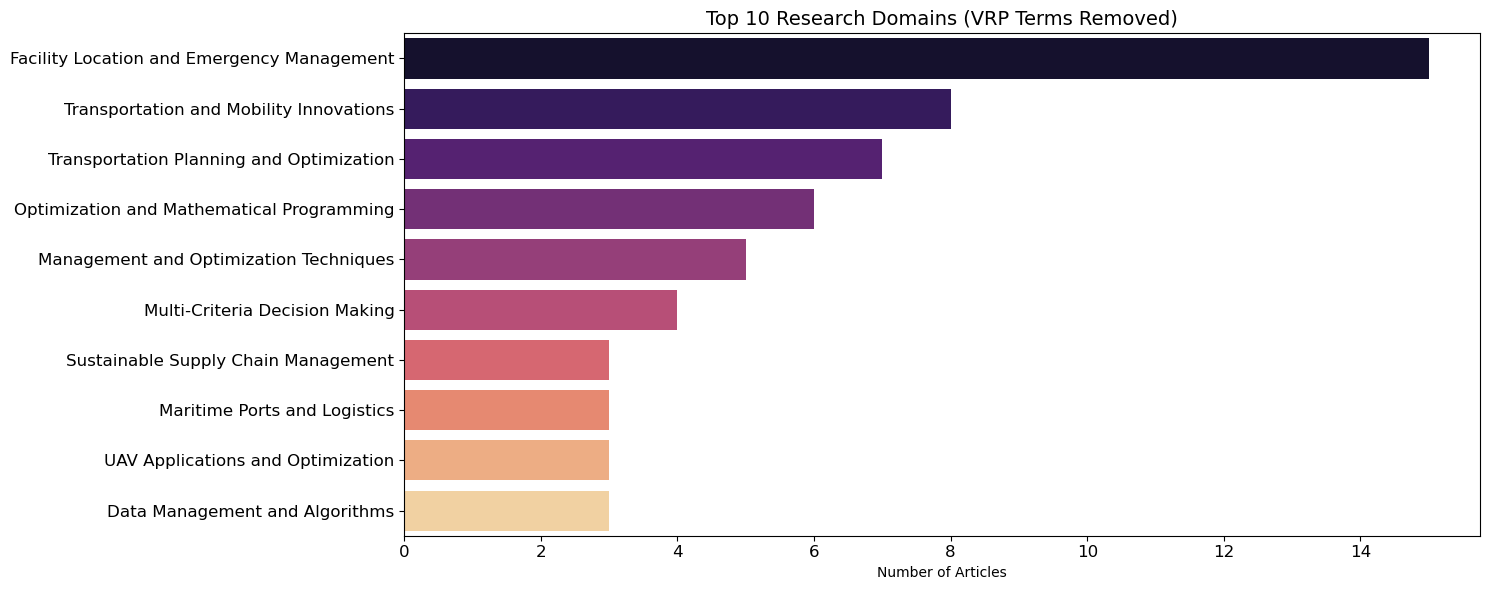

In [51]:

plot_real_trends(df_recent)

## Top Cited Articles

In [52]:

show_top_cited(df_recent)

,display_name,primary_author,publication_year,cited_by_count
26,Location-routing problem in multimodal transpo...,Saeed Fazayeli,2018,153
12,An ant colony system empowered variable neighb...,Can B. Kalaycı,2016,141
17,Multi-objective optimization of a two-echelon ...,Alexandra Anderluh,2019,140
57,Two-echelon location-routing optimization with...,Yong Wang,2018,125
8,Deep reinforcement learning for the dynamic an...,Weixu Pan,2022,120
11,ADMM-based problem decomposition scheme for ve...,Yu Yao,2019,118
15,An innovative waste management system in a sma...,Navid Akbarpour,2021,114
18,FH-ACO Fuzzy heuristic-based ant colony optimi...,Mohammad Shokouhifar,2021,88
43,A TimeDependent Fuzzy Programming Approach for...,Yan Sun,2018,79
2,Reverse logistics optimization of an industria...,Sadia Samar Ali,2020,77


## Top Authors

### Per citations

/tmp/ipykernel_1792766/2788011657.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_data.values, y=top_data.index, palette=palette)


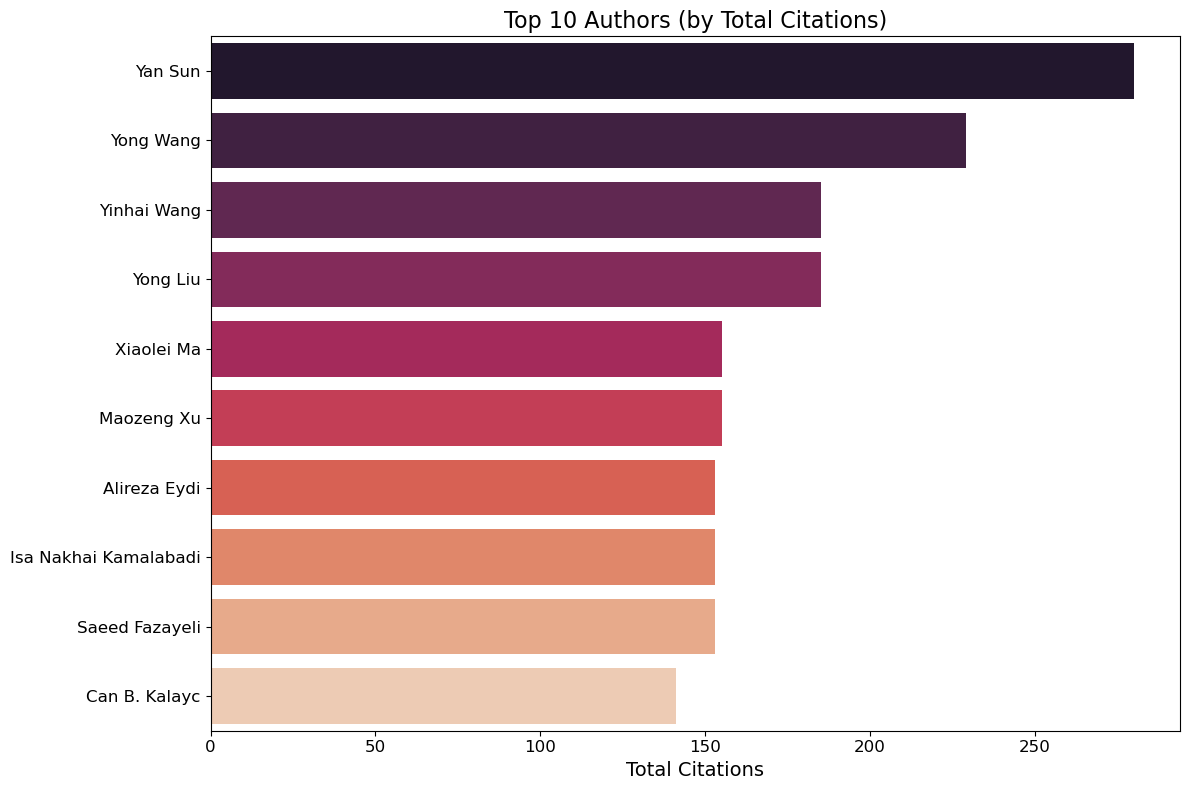

authorships.author.display_name
Yan Sun                  280
Yong Wang                229
Yinhai Wang              185
Yong Liu                 185
Xiaolei Ma               155
Maozeng Xu               155
Alireza Eydi             153
Isa Nakhai Kamalabadi    153
Saeed Fazayeli           153
Can B. Kalayc            141
Name: cited_by_count, dtype: int64

In [53]:
plot_top_stats(df_recent,category = 'author', metric='citations')

### Per publications

/tmp/ipykernel_1792766/2788011657.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_data.values, y=top_data.index, palette=palette)


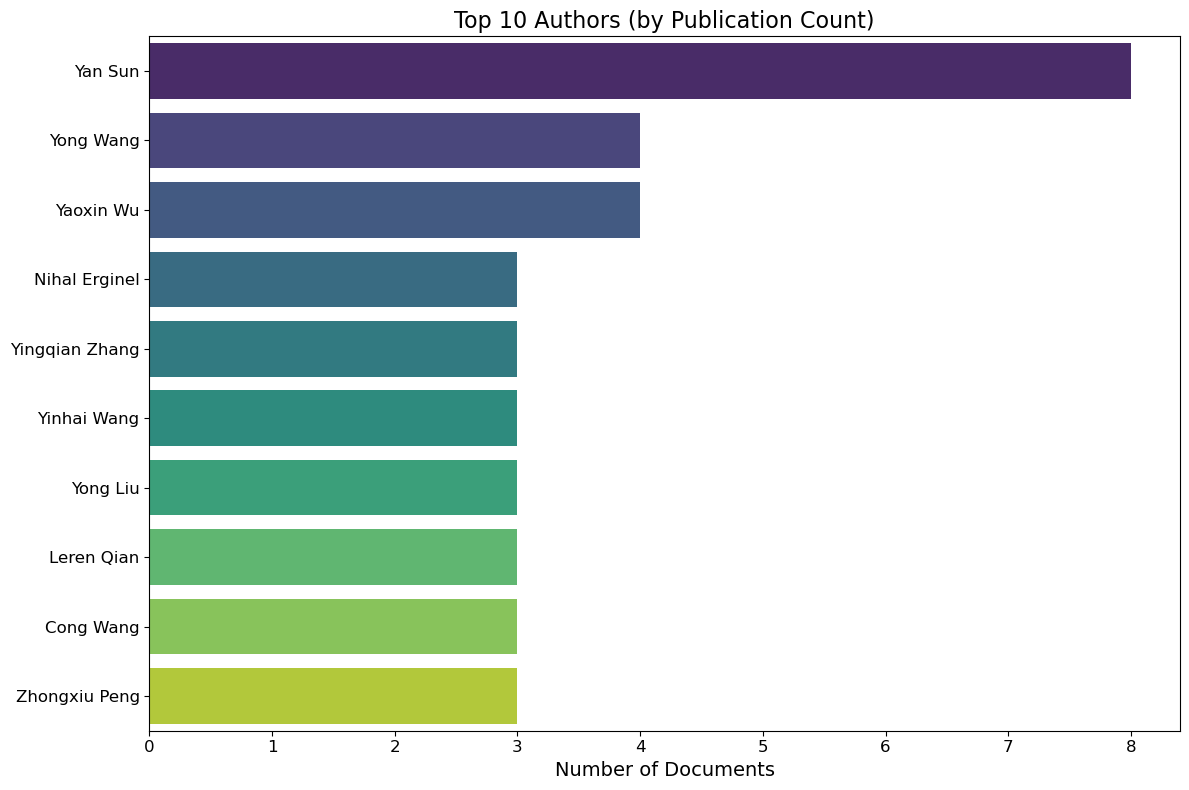

authorships.author.display_name
Yan Sun           8
Yong Wang         4
Yaoxin Wu         4
Nihal Erginel     3
Yingqian Zhang    3
Yinhai Wang       3
Yong Liu          3
Leren Qian        3
Cong Wang         3
Zhongxiu Peng     3
dtype: int64

In [54]:
plot_top_stats(df_recent,category = 'author',metric='publications')

## Top Institutions

### Per citations

/tmp/ipykernel_1792766/2788011657.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_data.values, y=top_data.index, palette=palette)


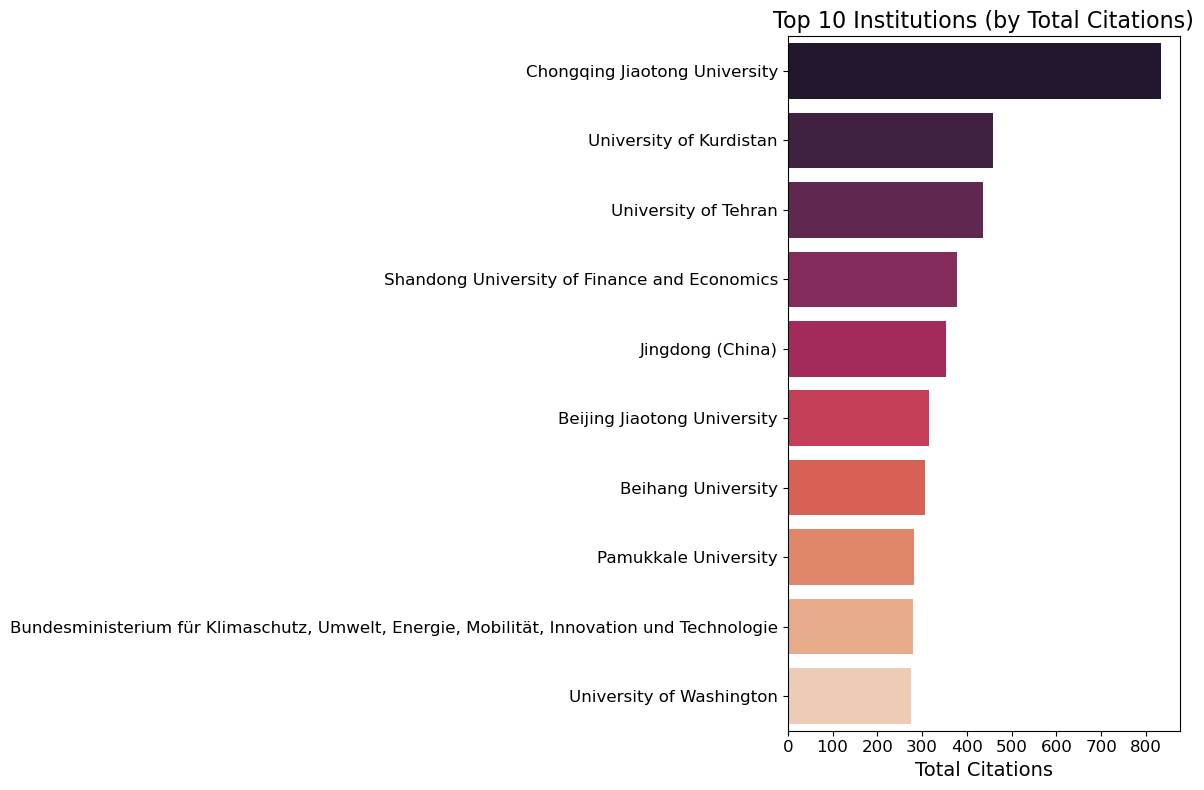

authorships.institutions.display_name
Chongqing Jiaotong University                                                                834
University of Kurdistan                                                                      459
University of Tehran                                                                         435
Shandong University of Finance and Economics                                                 379
Jingdong (China)                                                                             354
Beijing Jiaotong University                                                                  315
Beihang University                                                                           307
Pamukkale University                                                                         282
Bundesministerium für Klimaschutz, Umwelt, Energie, Mobilität, Innovation und Technologie    280
University of Washington                                                                 

In [55]:
plot_top_stats(df_recent,category = 'institution', metric='citations')

### Per Publications

/tmp/ipykernel_1792766/2788011657.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_data.values, y=top_data.index, palette=palette)


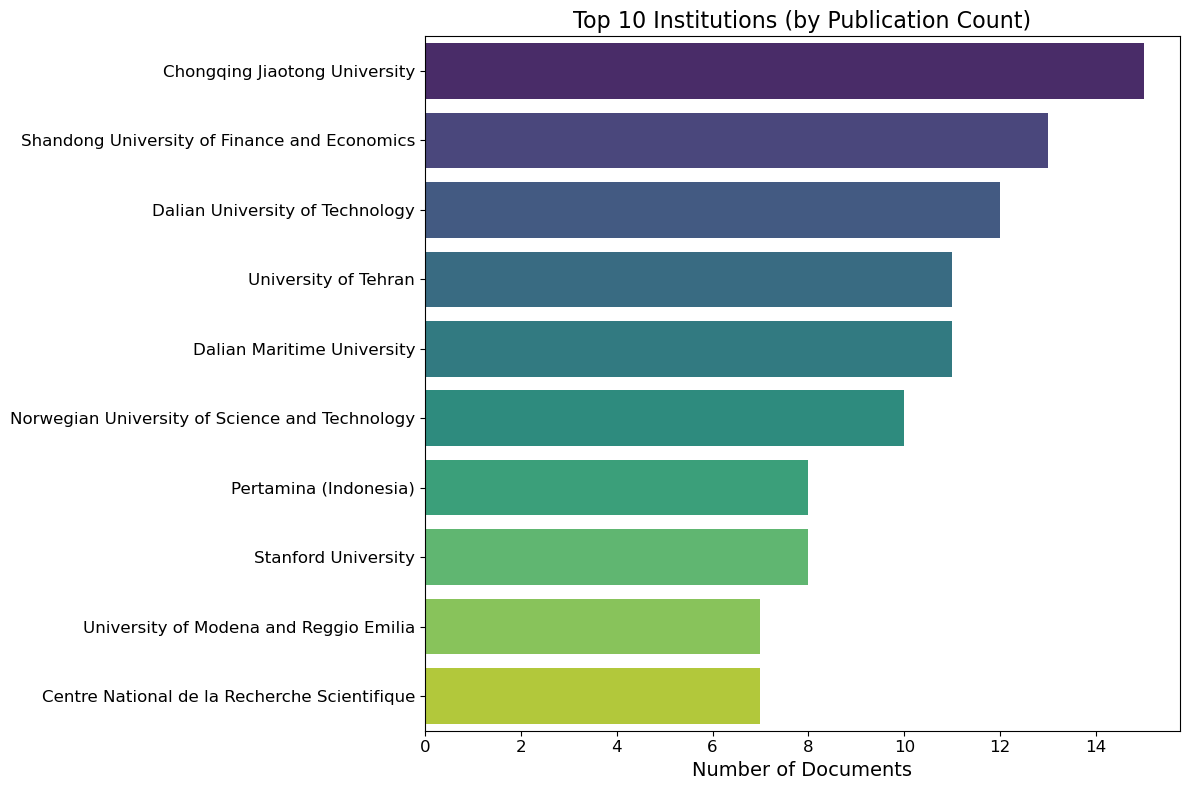

authorships.institutions.display_name
Chongqing Jiaotong University                     15
Shandong University of Finance and Economics      13
Dalian University of Technology                   12
University of Tehran                              11
Dalian Maritime University                        11
Norwegian University of Science and Technology    10
Pertamina (Indonesia)                              8
Stanford University                                8
University of Modena and Reggio Emilia             7
Centre National de la Recherche Scientifique       7
dtype: int64

In [56]:
plot_top_stats(df_recent,category = 'institution', metric='publications')

## Top Countries

### Per citations

/tmp/ipykernel_1792766/2788011657.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_data.values, y=top_data.index, palette=palette)


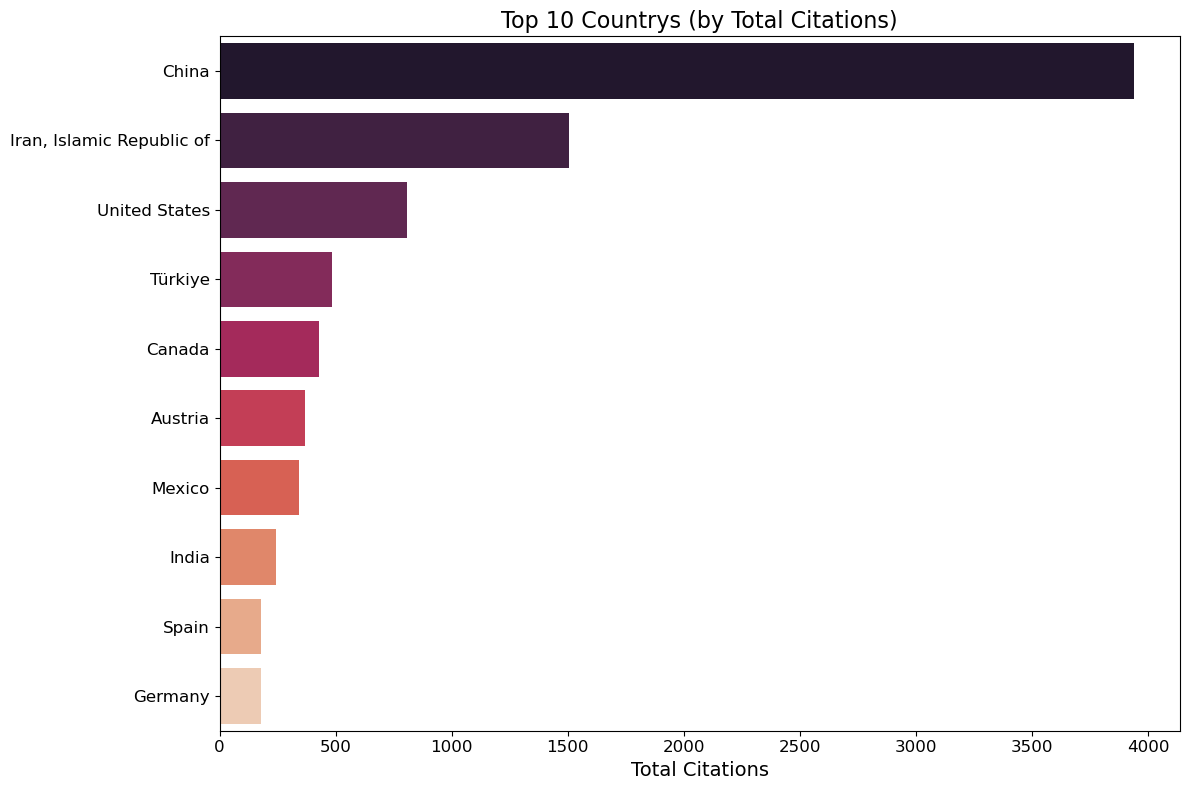

authorships.countries
China                        3941
Iran, Islamic Republic of    1504
United States                 809
Türkiye                       485
Canada                        430
Austria                       367
Mexico                        342
India                         244
Spain                         178
Germany                       177
Name: cited_by_count, dtype: int64

In [57]:
plot_top_stats(df_recent,category = 'country', metric='citations')

### Per publications

/tmp/ipykernel_1792766/2788011657.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_data.values, y=top_data.index, palette=palette)


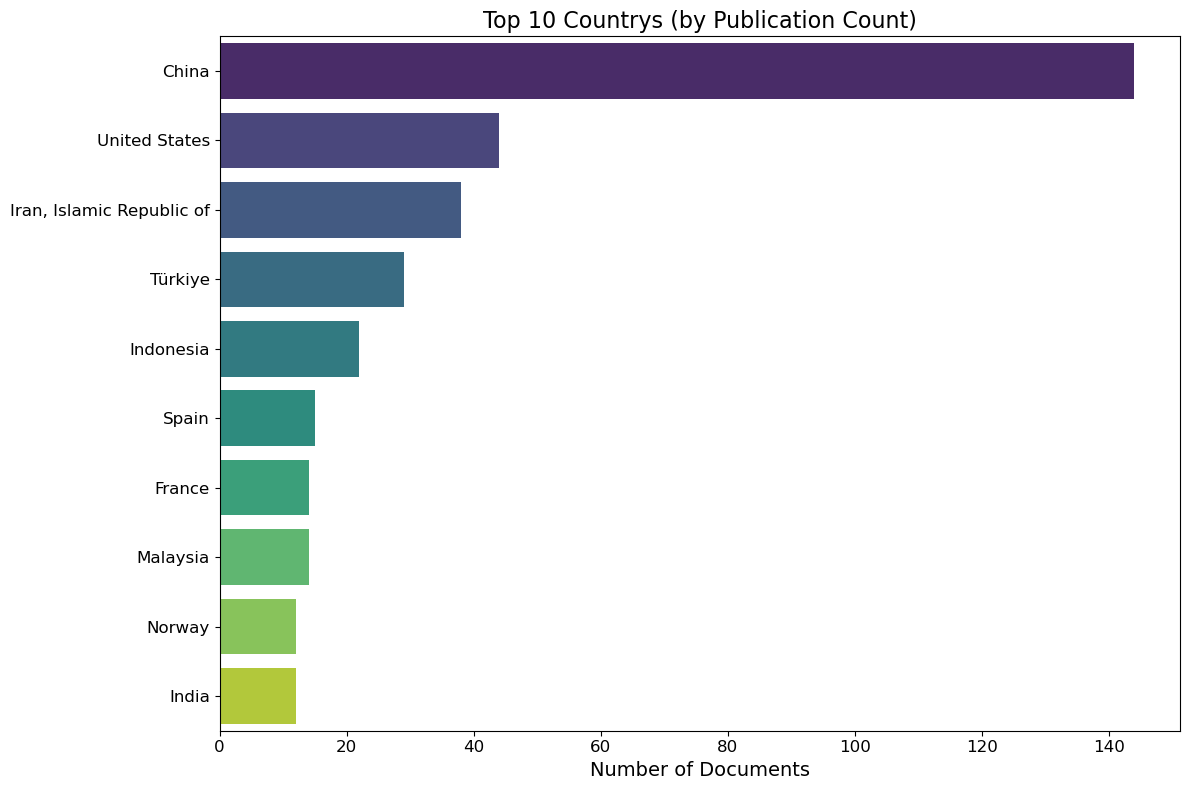

authorships.countries
China                        144
United States                 44
Iran, Islamic Republic of     38
Türkiye                       29
Indonesia                     22
Spain                         15
France                        14
Malaysia                      14
Norway                        12
India                         12
dtype: int64

In [58]:
plot_top_stats(df_recent,category = 'country', metric='publications')

## Colaborations

Showing top 3 author clusters.


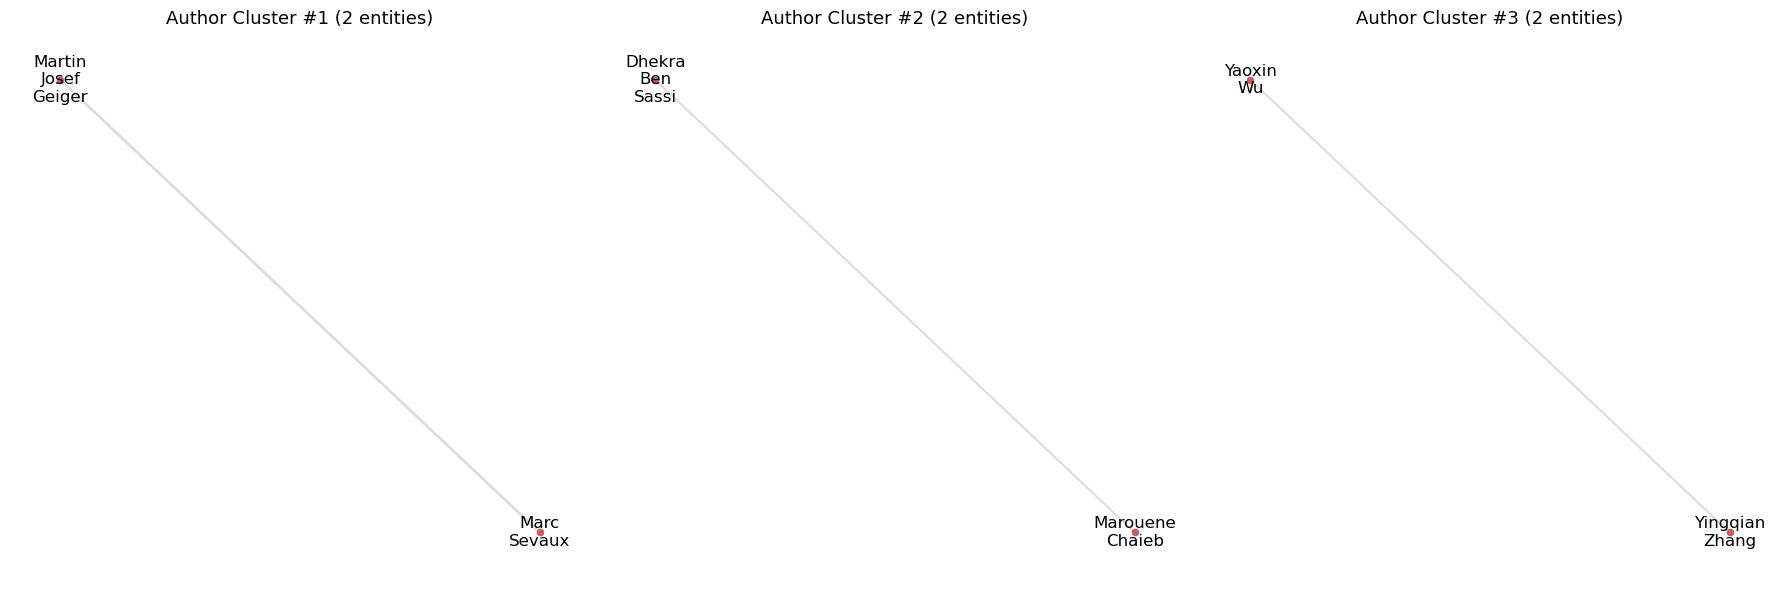

In [63]:
analyze_category_clusters(df_clean, category='author', min_shared=3, grid_rows=1, grid_cols=3,font_size=12)

Showing top 1 country clusters.


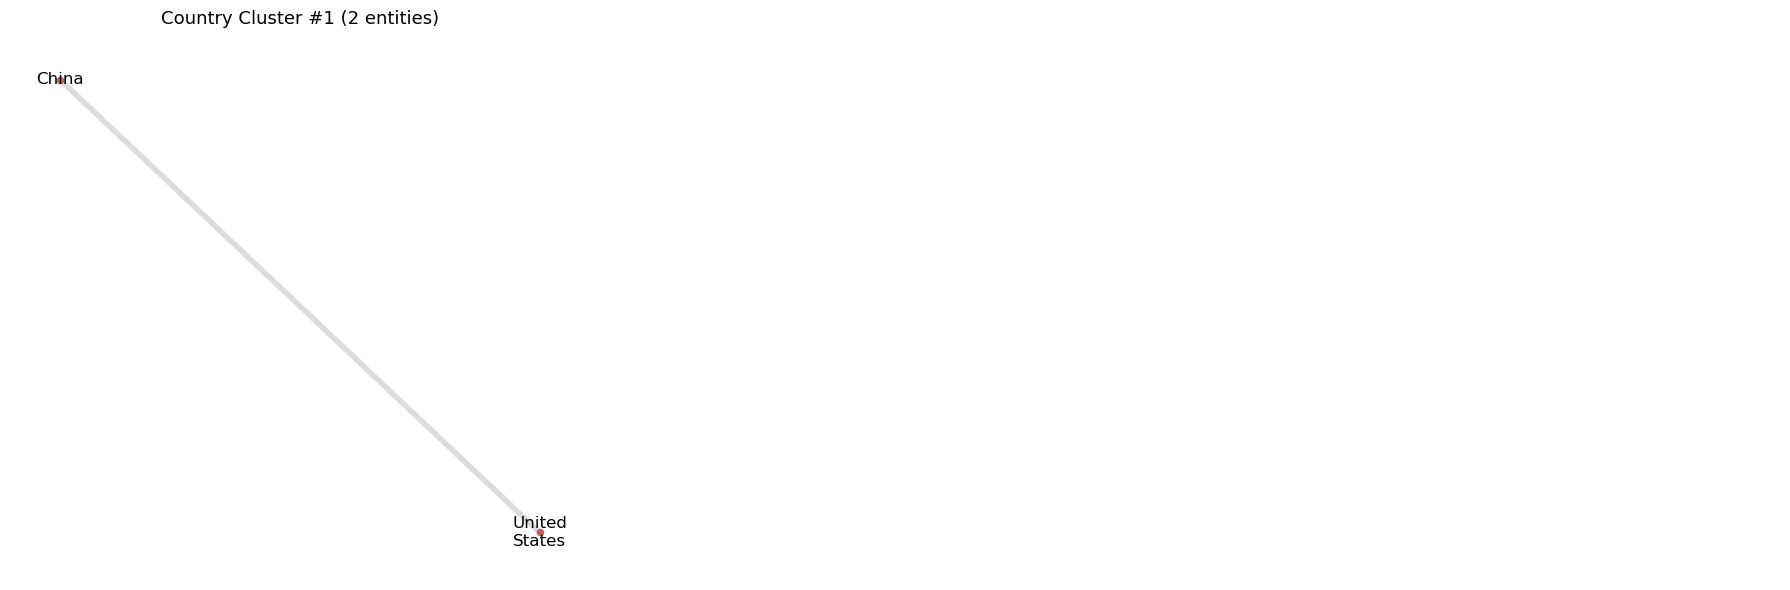

In [64]:

# --- Example Usages ---
analyze_category_clusters(df_clean, category='country', min_shared=5, grid_rows=1, grid_cols=3)

Showing top 2 institution clusters.


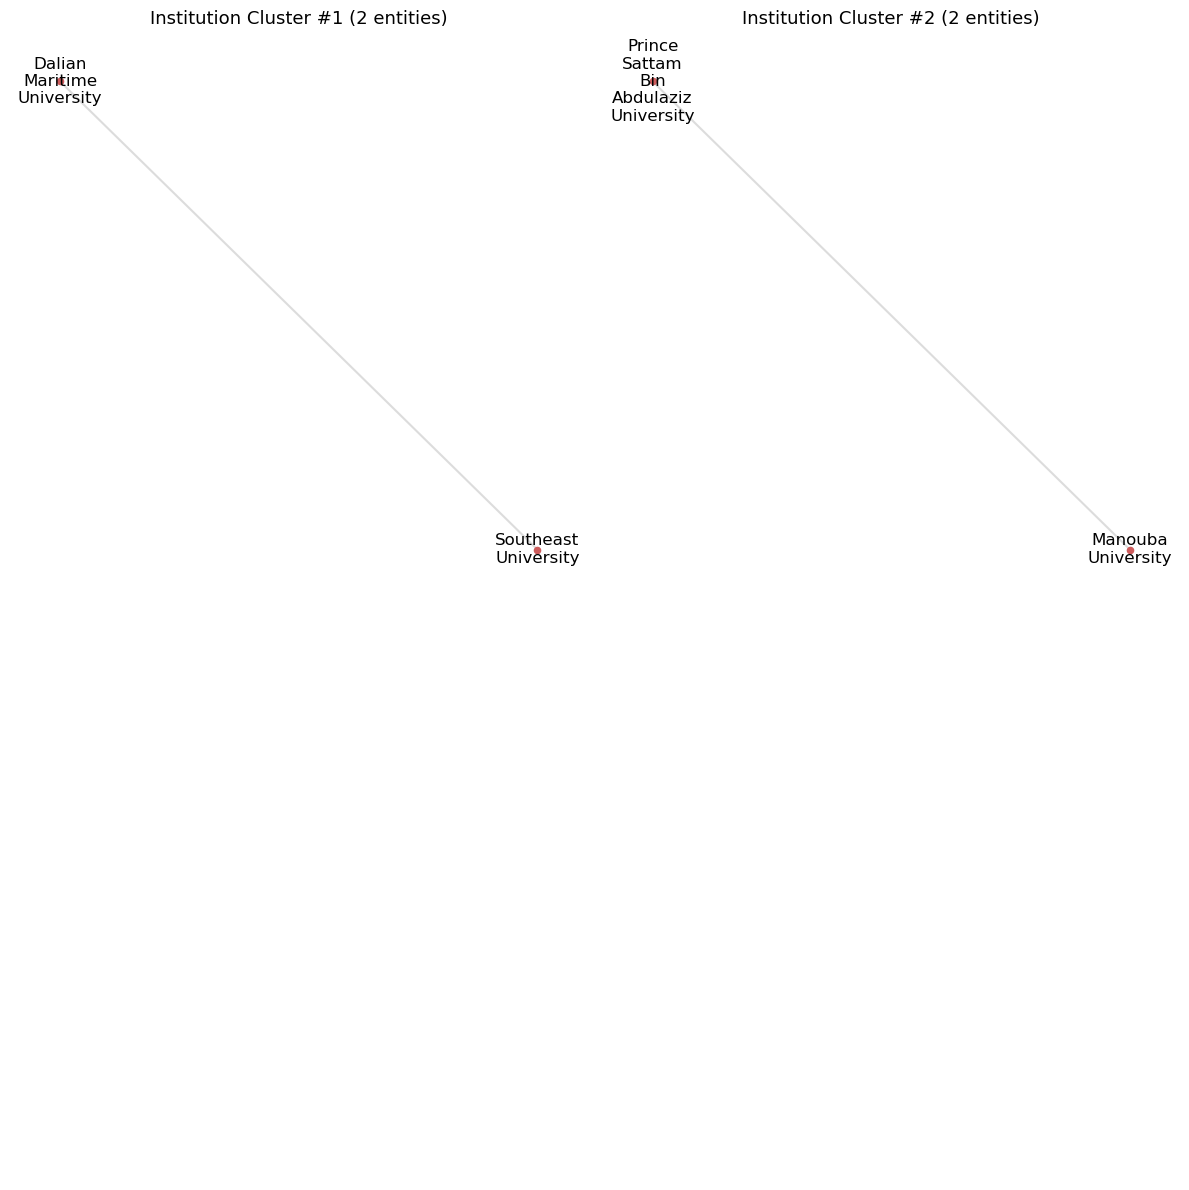

In [65]:
analyze_category_clusters(df_clean, category='institution', min_shared=3, grid_rows=2, grid_cols=2)